# 🌾 FarmTech Solutions - Análise de Rendimento de Safras

## Projeto: Previsão de Rendimento de Culturas Agrícolas - Fase 5

**Contexto:** Análise de dados de uma fazenda de 200 hectares com múltiplas culturas.

**Objetivos:**
1. Análise exploratória dos dados (EDA)
2. Clusterização para identificar tendências e outliers
3. Modelos preditivos de regressão para prever rendimento

---

## 👥 Integrantes

- Davis Roberto - RM567941
- Guilherme Chan - RM567722
- Deivid Paula da Silva Oliveira - RM566752
- Guilherme Paes Barreto Didier Garcia - RM568457

---

## 📦 1. Importação de Bibliotecas

In [6]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Pré-processamento
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning - Modelos de Regressão
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# Machine Learning - Clusterização
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Métricas
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             mean_absolute_percentage_error, silhouette_score)

# Detecção de outliers
from scipy import stats
from sklearn.ensemble import IsolationForest

# Configurações
import warnings
warnings.filterwarnings('ignore')

# Seed para reprodutibilidade
np.random.seed(42)

# Configuração de visualização
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
sns.set_palette('husl')

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


## 📊 2. Carregamento e Visão Geral dos Dados

In [7]:
# Carregar o dataset
# Certifique-se de que o arquivo 'crop_yield.csv' foi carregado para o ambiente do Colab, por exemplo, na pasta /content/
df = pd.read_csv('/content/crop_yield.csv')

print(f'📁 Dataset carregado com sucesso!')
print(f'Dimensões: {df.shape[0]} linhas e {df.shape[1]} colunas\n')

# Exibir primeiras linhas
print('🔍 Primeiras 10 linhas do dataset:')
df.head(10)

📁 Dataset carregado com sucesso!
Dimensões: 156 linhas e 6 colunas

🔍 Primeiras 10 linhas do dataset:


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800
5,"Cocoa, beans",2339.30,17.70,84.54,25.76,8850
6,"Cocoa, beans",2326.09,18.09,84.63,26.11,9003
7,"Cocoa, beans",2718.08,18.30,85.43,26.12,9880
8,"Cocoa, beans",2061.61,17.80,84.36,25.88,9201
9,"Cocoa, beans",1934.62,17.94,83.43,26.21,8300


In [8]:
# Informações gerais do dataset
print('ℹ️ Informações do Dataset:')
print('='*70)
df.info()

ℹ️ Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


In [9]:
# Verificar nomes das colunas
print('📋 Colunas do dataset:')
for i, col in enumerate(df.columns, 1):
    print(f'{i}. {col}')
print(f'\nTotal: {len(df.columns)} colunas')

📋 Colunas do dataset:
1. Crop
2. Precipitation (mm day-1)
3. Specific Humidity at 2 Meters (g/kg)
4. Relative Humidity at 2 Meters (%)
5. Temperature at 2 Meters (C)
6. Yield

Total: 6 colunas


In [10]:
# Análise de valores nulos
print('🔍 Análise de Valores Nulos:')
print('='*70)
missing = pd.DataFrame({
    'Total Nulos': df.isnull().sum(),
    'Percentual (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Total Nulos'] > 0]

if len(missing) == 0:
    print('✅ Não há valores nulos no dataset!')
else:
    print(missing)

🔍 Análise de Valores Nulos:
✅ Não há valores nulos no dataset!


In [11]:
# Análise de duplicatas
duplicates = df.duplicated().sum()
print(f'🔍 Análise de Duplicatas:')
print('='*70)
print(f'Total de linhas duplicadas: {duplicates}')
print(f'Percentual: {(duplicates/len(df)*100):.2f}%')

if duplicates == 0:
    print('\n✅ Não há linhas duplicadas!')

🔍 Análise de Duplicatas:
Total de linhas duplicadas: 0
Percentual: 0.00%

✅ Não há linhas duplicadas!


## 📈 3. Estatísticas Descritivas

In [12]:
# Estatísticas descritivas das variáveis numéricas
print('📊 Estatísticas Descritivas das Variáveis Numéricas:')
print('='*90)
df.describe().T

📊 Estatísticas Descritivas das Variáveis Numéricas:


,count,mean,std,min,25%,50%,75%,max
Precipitation (mm day-1),156.0,2486.498974,289.457914,1934.62,2302.99,2424.55,2718.08,3085.79
Specific Humidity at 2 Meters (g/kg),156.0,18.203077,0.293923,17.54,18.03,18.27,18.40,18.70
Relative Humidity at 2 Meters (%),156.0,84.737692,0.996226,82.11,84.12,84.85,85.51,86.10
Temperature at 2 Meters (C),156.0,26.183590,0.261050,25.56,26.02,26.13,26.30,26.81
Yield,156.0,56153.096154,70421.958897,5249.00,8327.75,18871.00,67518.75,203399.00


🌾 Análise das Culturas (Crop):
Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64

Total de culturas diferentes: 4


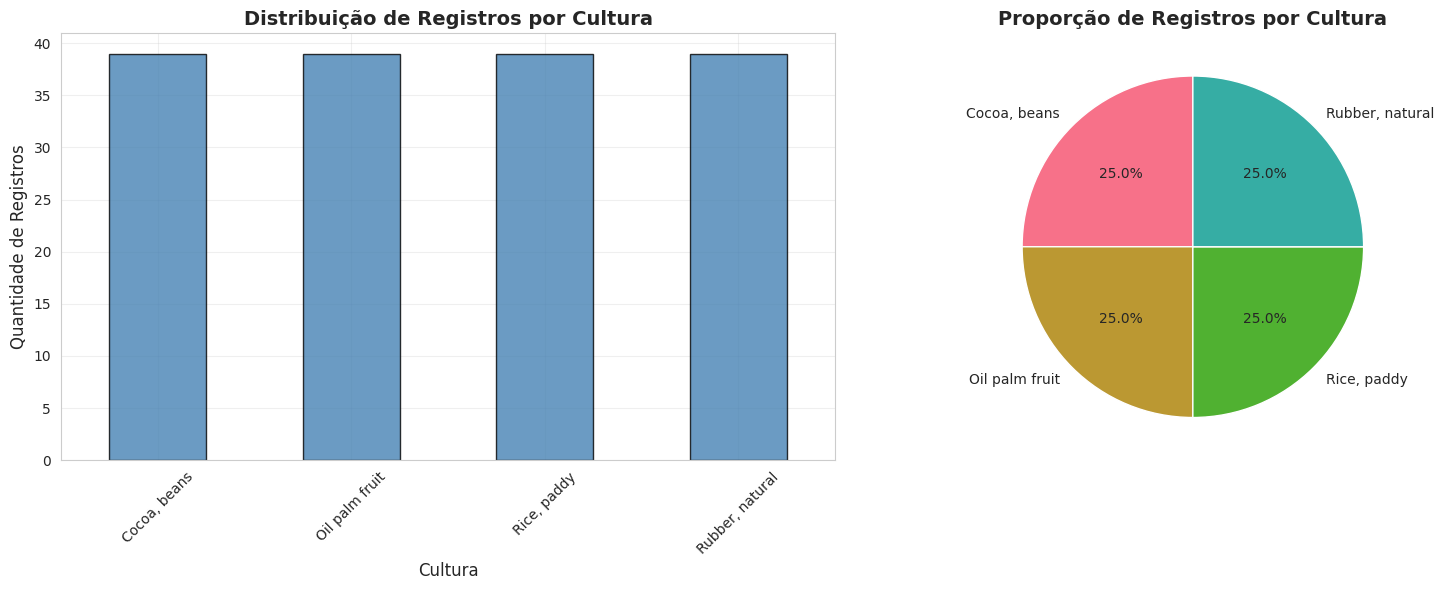

In [13]:
# Análise das culturas
print('🌾 Análise das Culturas (Crop):')
print('='*70)
crop_counts = df['Crop'].value_counts()
print(crop_counts)
print(f'\nTotal de culturas diferentes: {df["Crop"].nunique()}')

# Visualização
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
crop_counts.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_title('Distribuição de Registros por Cultura', fontsize=14, fontweight='bold')
ax1.set_xlabel('Cultura', fontsize=12)
ax1.set_ylabel('Quantidade de Registros', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(alpha=0.3)

# Gráfico de pizza
ax2.pie(crop_counts.values, labels=crop_counts.index, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 10})
ax2.set_title('Proporção de Registros por Cultura', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 📊 4. Distribuição das Variáveis Numéricas

Variáveis numéricas encontradas: ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)', 'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']



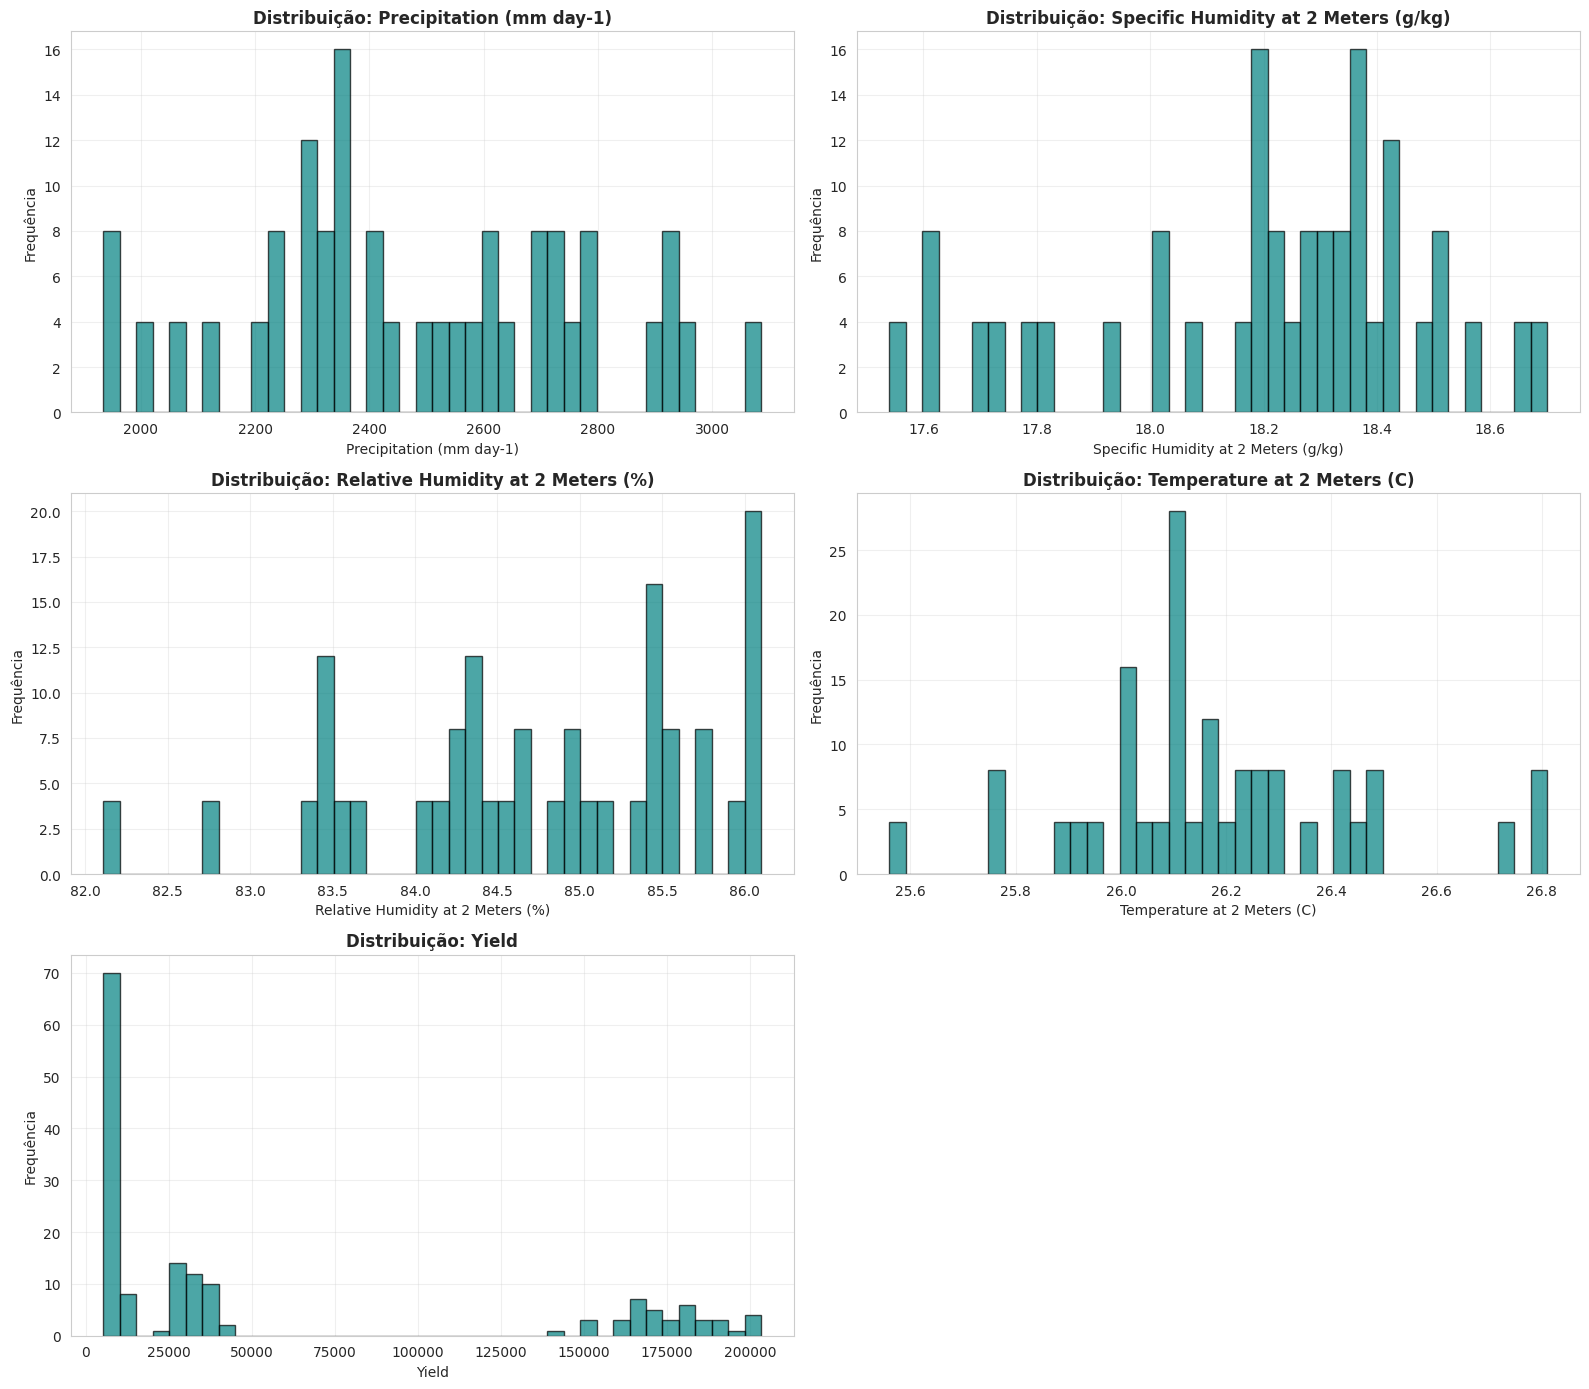

In [14]:
# Selecionar apenas colunas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Variáveis numéricas encontradas: {numeric_cols}\n')

# Histogramas
n_cols = len(numeric_cols)
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        axes[i].hist(df[col].dropna(), bins=40, color='teal', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Distribuição: {col}', fontweight='bold', fontsize=12)
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel('Frequência', fontsize=10)
        axes[i].grid(alpha=0.3)

# Remover subplots vazios
for i in range(n_cols, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

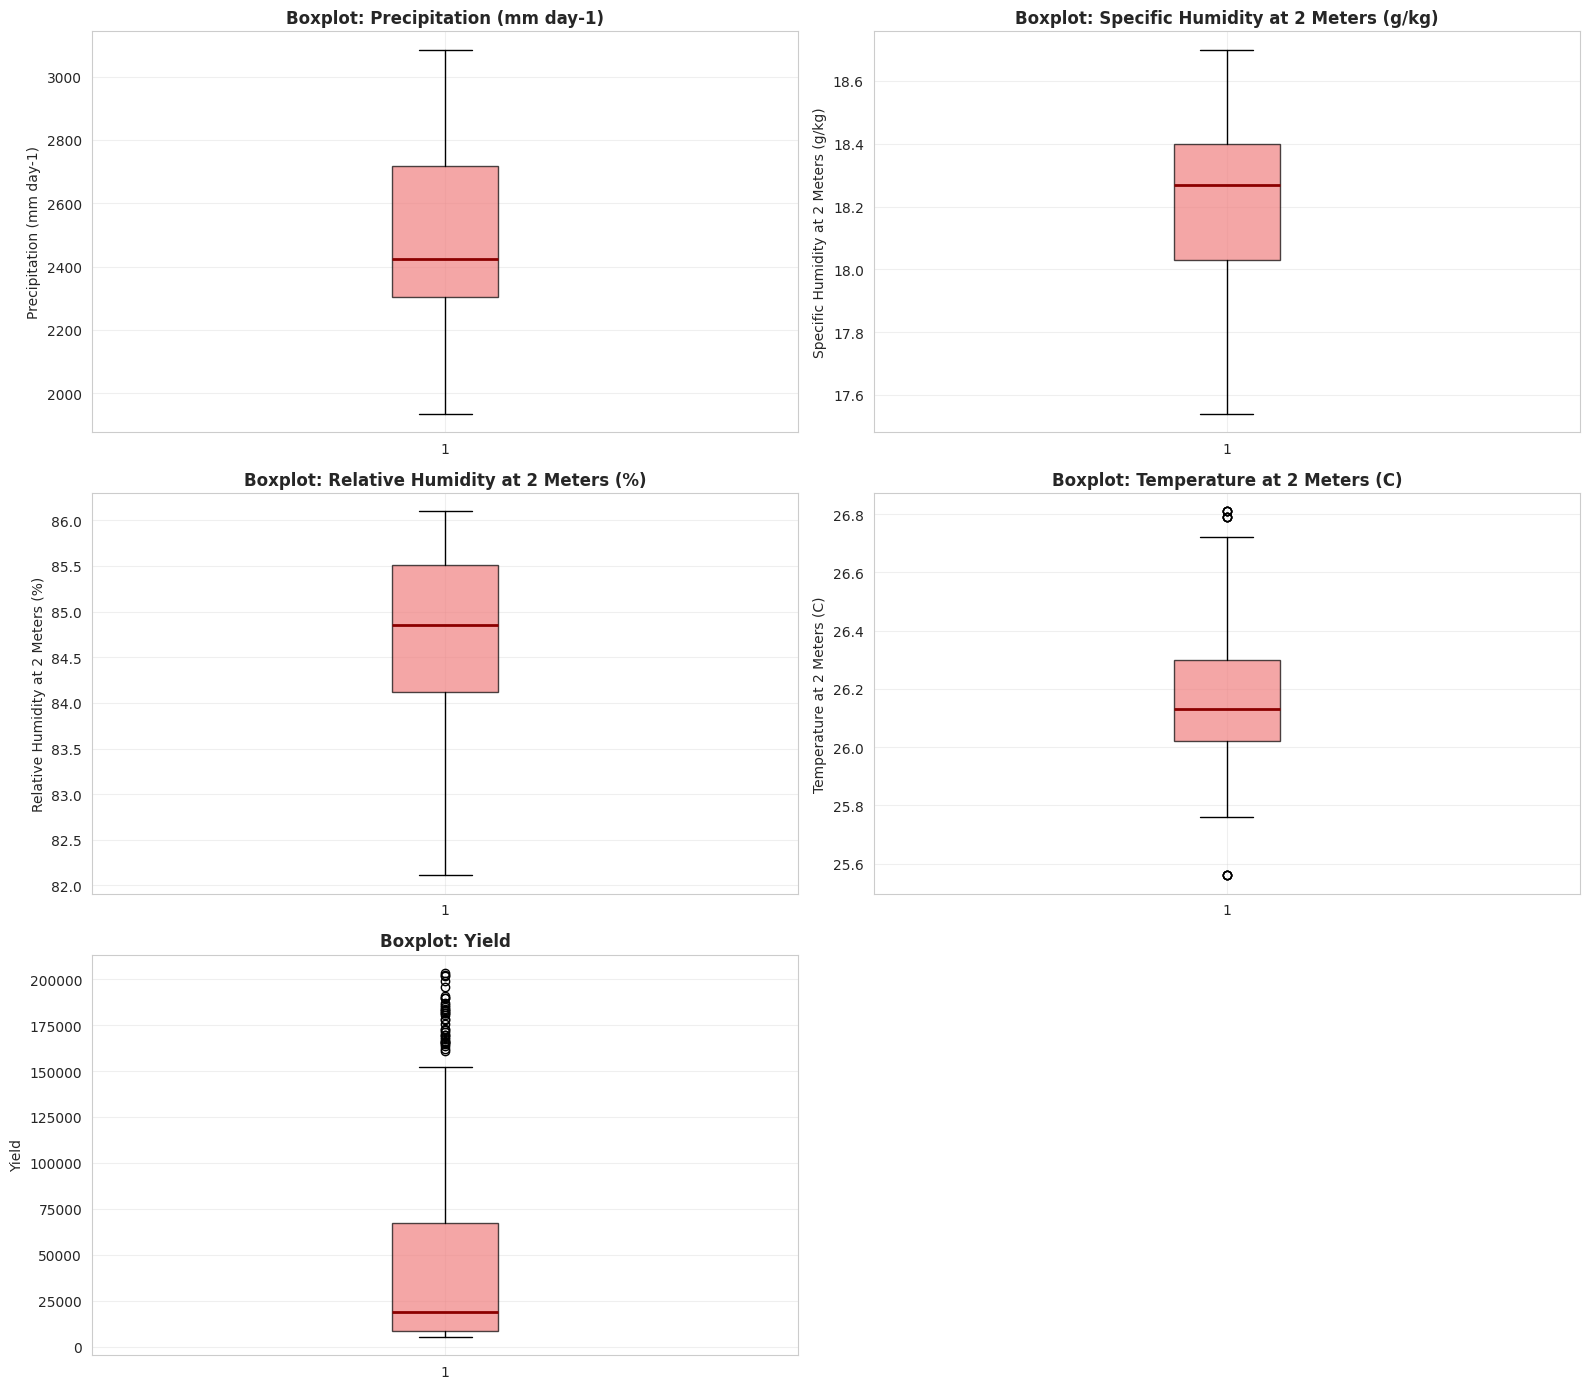

In [15]:
# Boxplots para identificar outliers
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        bp = axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                            boxprops=dict(facecolor='lightcoral', alpha=0.7),
                            medianprops=dict(color='darkred', linewidth=2))
        axes[i].set_title(f'Boxplot: {col}', fontweight='bold', fontsize=12)
        axes[i].set_ylabel(col, fontsize=10)
        axes[i].grid(alpha=0.3)

# Remover subplots vazios
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## 🔗 5. Análise de Correlação

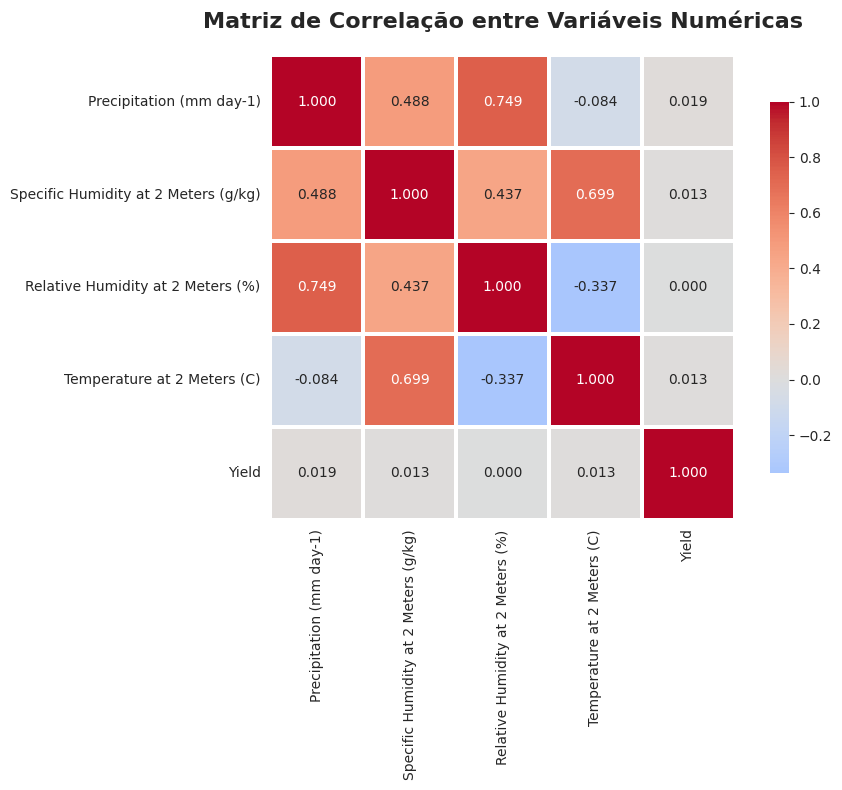


🔍 Correlações com a variável alvo (Yield):
Yield                                   1.000000
Precipitation (mm day-1)                0.018830
Temperature at 2 Meters (C)             0.013007
Specific Humidity at 2 Meters (g/kg)    0.012651
Relative Humidity at 2 Meters (%)       0.000008
Name: Yield, dtype: float64


In [16]:
# Matriz de correlação
correlation_matrix = df[numeric_cols].corr()

# Visualização da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação entre Variáveis Numéricas',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print('\n🔍 Correlações com a variável alvo (Yield):')
print('='*70)
correlations_with_yield = correlation_matrix['Yield'].sort_values(ascending=False)
print(correlations_with_yield)

📊 Gerando pairplot (pode demorar alguns segundos)...


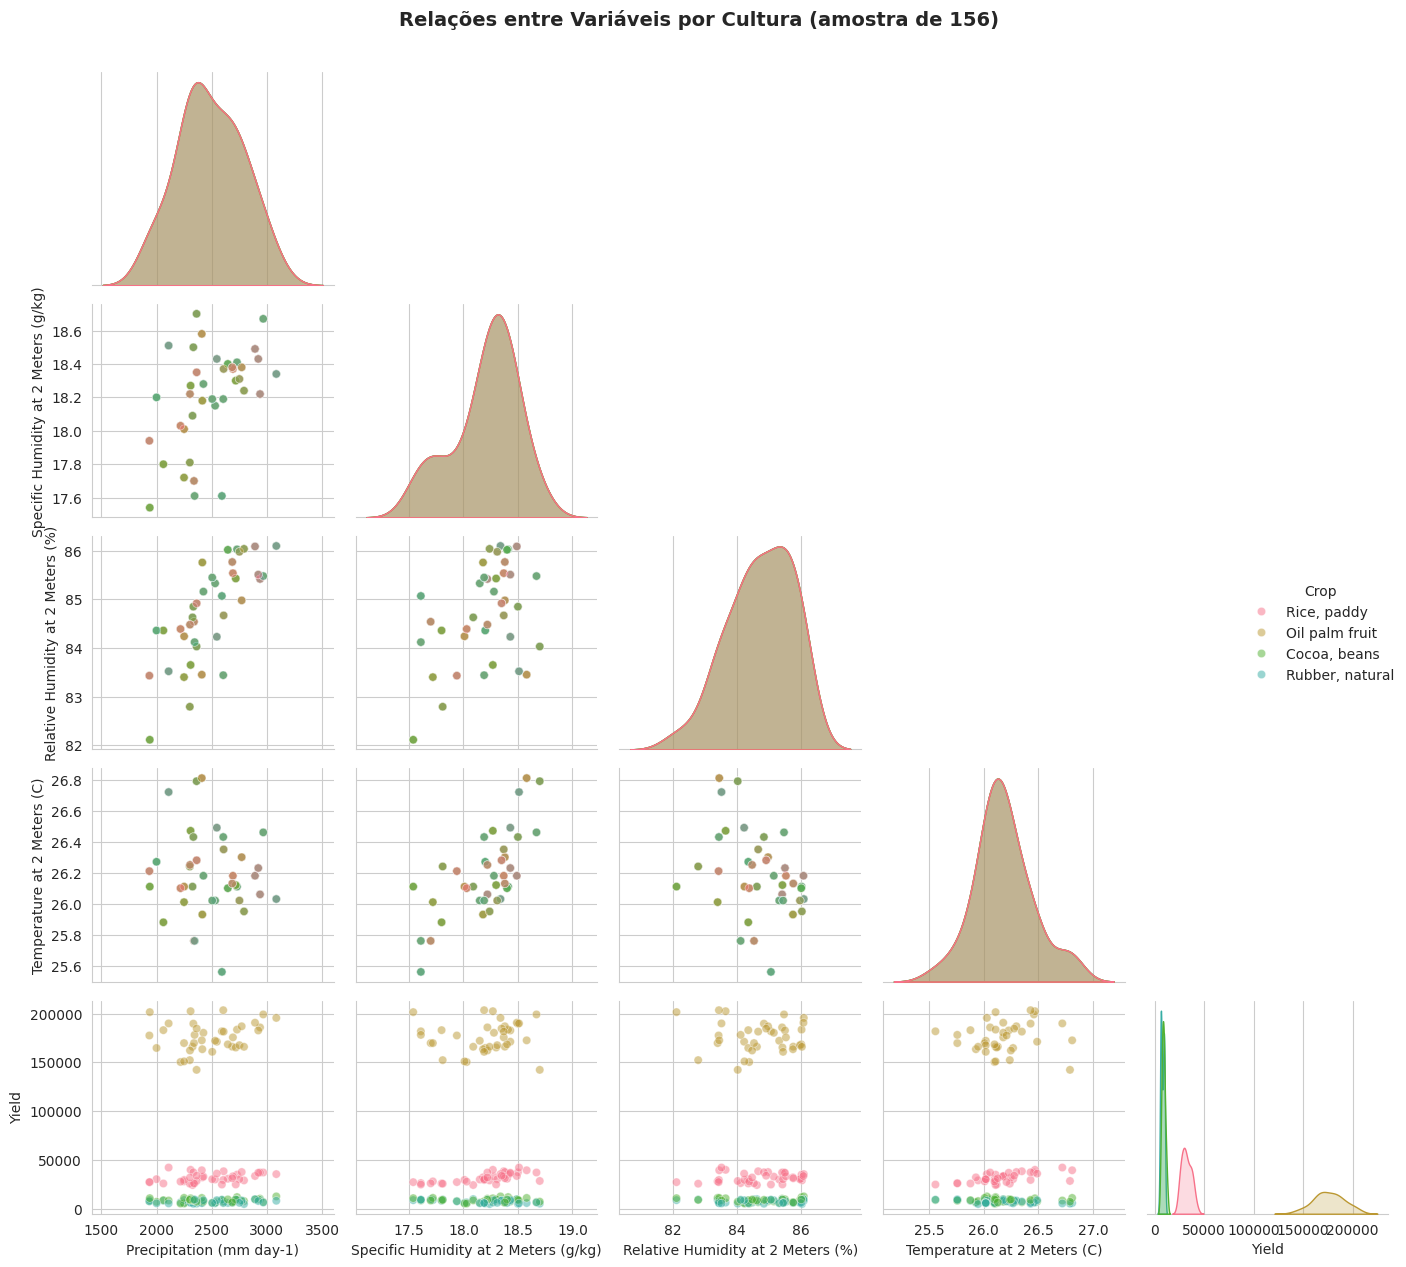

In [17]:
# Pairplot para visualizar relações entre variáveis
print('📊 Gerando pairplot (pode demorar alguns segundos)...')
sample_size = min(1000, len(df))  # Limitar para não sobrecarregar
df_sample = df.sample(n=sample_size, random_state=42)

sns.pairplot(df_sample, hue='Crop', diag_kind='kde', plot_kws={'alpha': 0.5},
             corner=True, height=2.5)
plt.suptitle(f'Relações entre Variáveis por Cultura (amostra de {sample_size})',
             y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🌾 6. Análise por Cultura

In [18]:
# Estatísticas de rendimento por cultura
print('📊 Estatísticas de Rendimento (Yield) por Cultura:')
print('='*90)
yield_stats = df.groupby('Crop')['Yield'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
yield_stats.columns = ['Quantidade', 'Média', 'Desvio Padrão', 'Mínimo', 'Máximo']
print(yield_stats.sort_values('Média', ascending=False))

📊 Estatísticas de Rendimento (Yield) por Cultura:
                 Quantidade      Média  Desvio Padrão  Mínimo  Máximo
Crop                                                                 
Oil palm fruit           39  175804.69       14919.87  142425  203399
Rice, paddy              39   32099.67        4789.95   24686   42550
Cocoa, beans             39    8883.13        1745.03    5765   13056
Rubber, natural          39    7824.90        1600.26    5249   10285


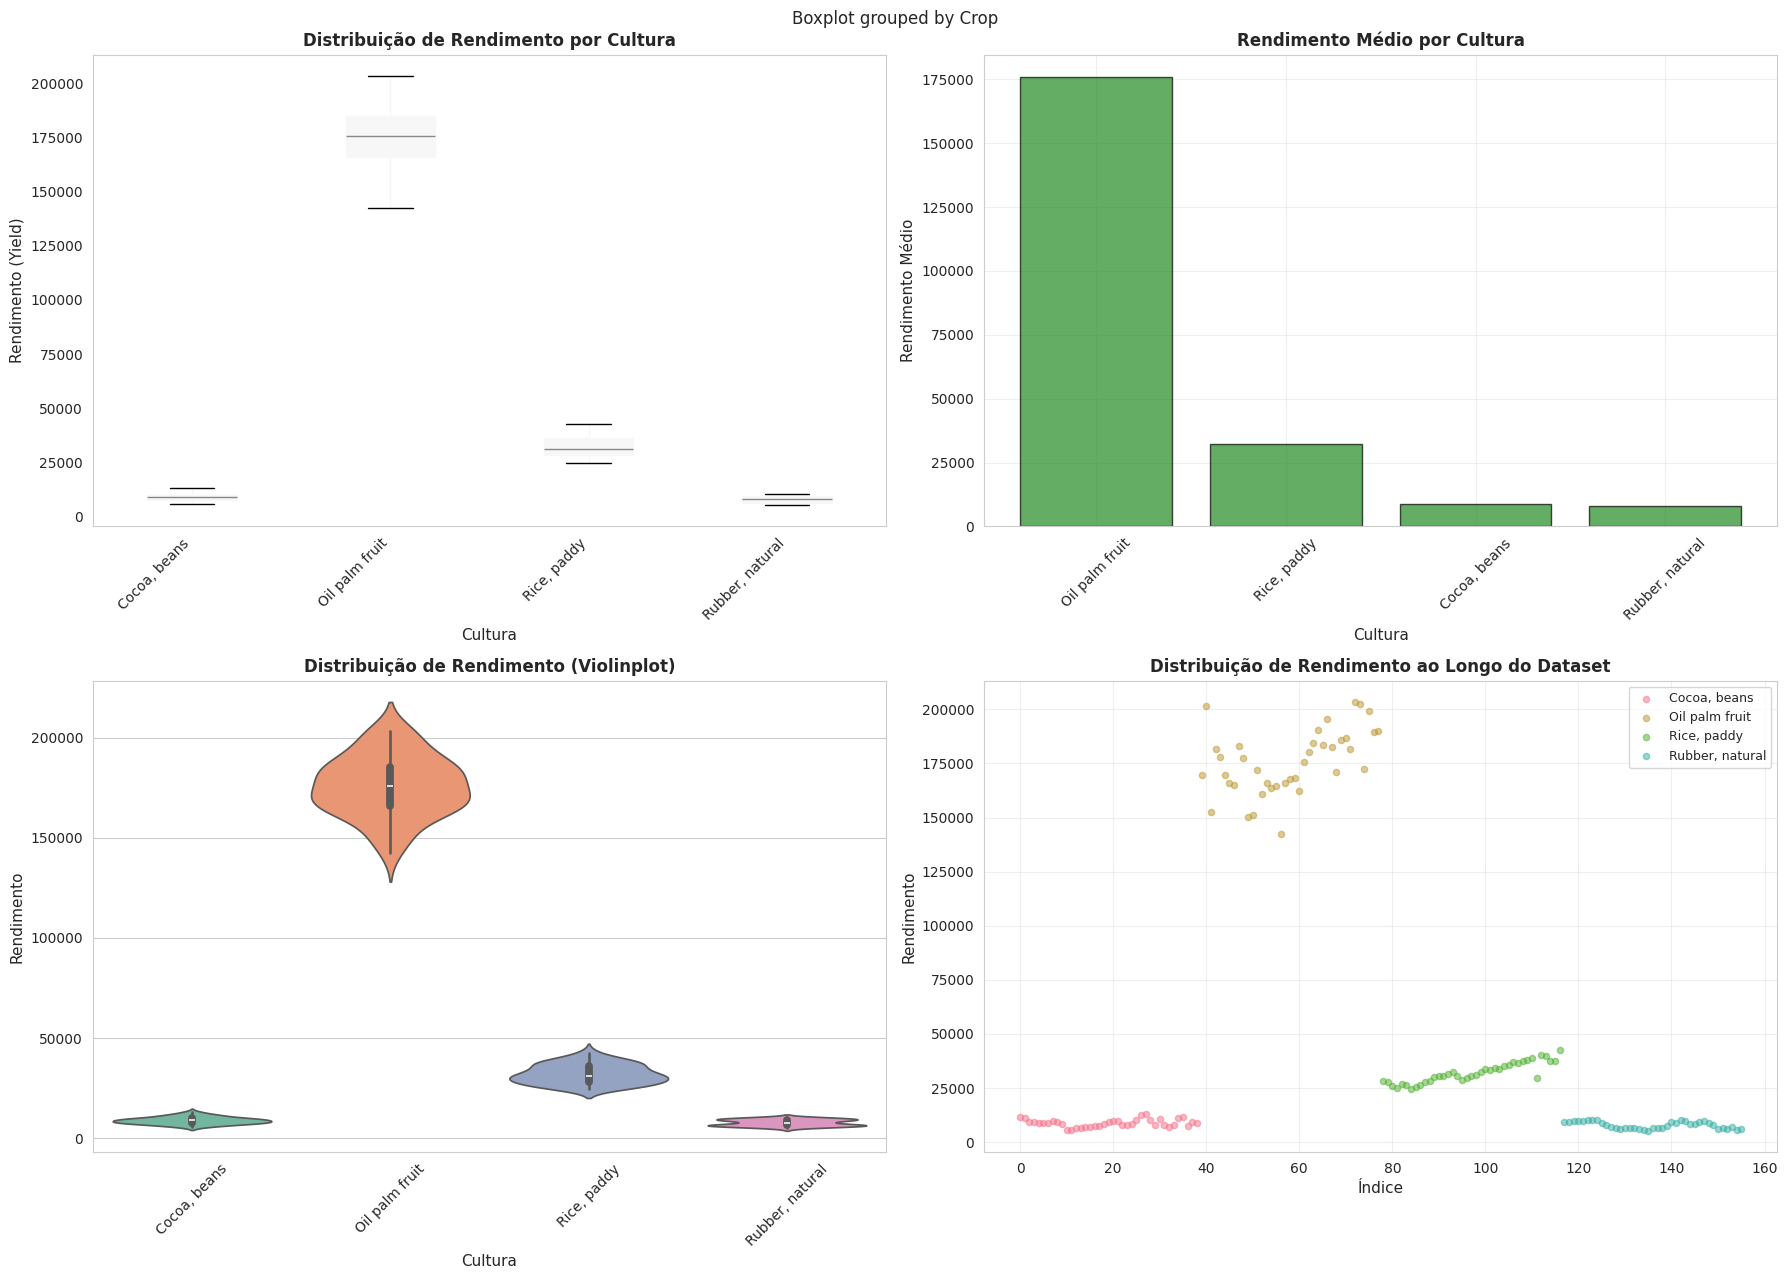

In [19]:
# Visualização do rendimento por cultura
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# 1. Boxplot
df.boxplot(column='Yield', by='Crop', ax=axes[0, 0], patch_artist=True, grid=False)
axes[0, 0].set_title('Distribuição de Rendimento por Cultura', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Cultura', fontsize=11)
axes[0, 0].set_ylabel('Rendimento (Yield)', fontsize=11)
axes[0, 0].tick_params(axis='x', rotation=45)
plt.sca(axes[0, 0])
plt.xticks(rotation=45, ha='right')

# 2. Barras de rendimento médio
yield_mean = df.groupby('Crop')['Yield'].mean().sort_values(ascending=False)
axes[0, 1].bar(yield_mean.index, yield_mean.values, color='forestgreen',
               alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Rendimento Médio por Cultura', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Cultura', fontsize=11)
axes[0, 1].set_ylabel('Rendimento Médio', fontsize=11)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(alpha=0.3)

# 3. Violinplot
sns.violinplot(data=df, x='Crop', y='Yield', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Distribuição de Rendimento (Violinplot)', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Cultura', fontsize=11)
axes[1, 0].set_ylabel('Rendimento', fontsize=11)
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Scatterplot com média
for crop in df['Crop'].unique():
    crop_data = df[df['Crop'] == crop]
    axes[1, 1].scatter(crop_data.index, crop_data['Yield'], alpha=0.5, label=crop, s=20)
axes[1, 1].set_title('Distribuição de Rendimento ao Longo do Dataset',
                     fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Índice', fontsize=11)
axes[1, 1].set_ylabel('Rendimento', fontsize=11)
axes[1, 1].legend(loc='best', fontsize=9)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

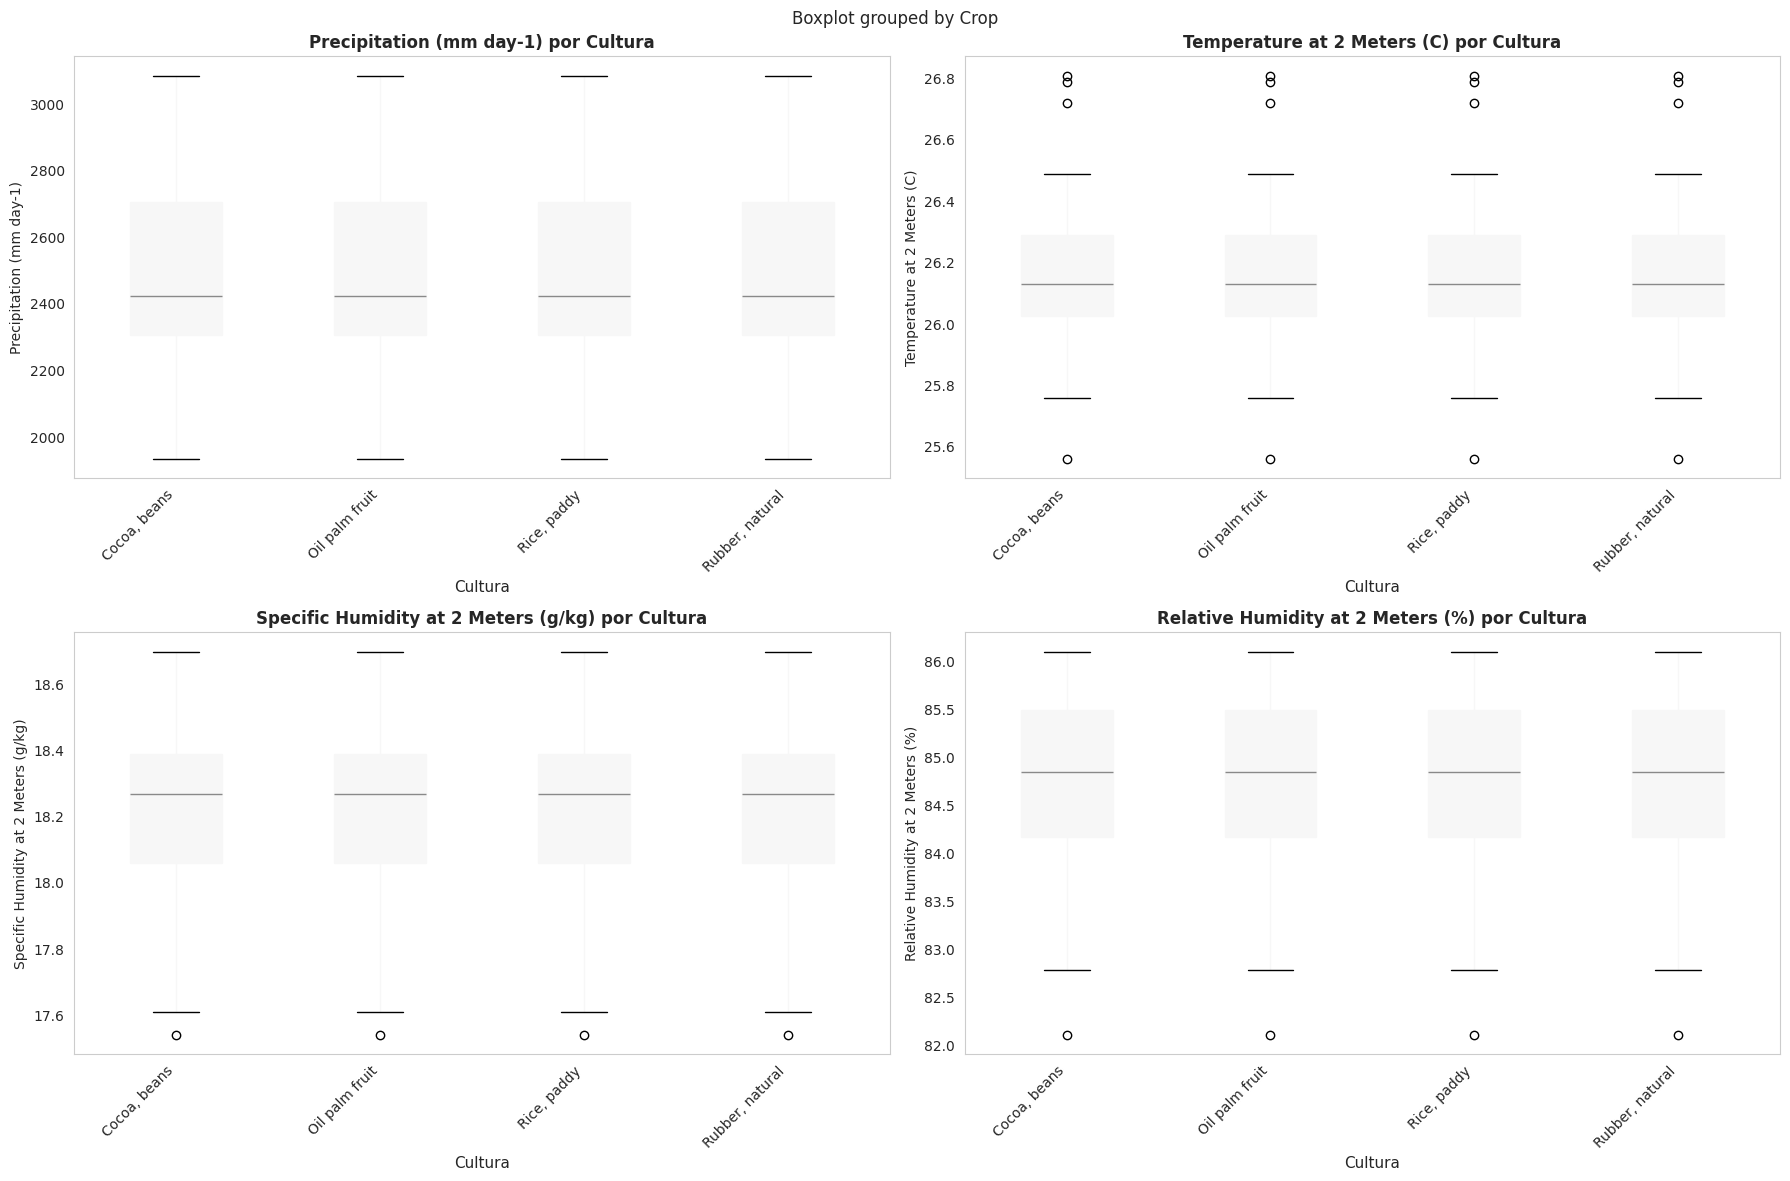

In [20]:
# Análise das condições climáticas por cultura
climate_vars = ['Precipitation (mm day-1)', 'Temperature at 2 Meters (C)',
                'Specific Humidity at 2 Meters (g/kg)', 'Relative Humidity at 2 Meters (%)']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for idx, var in enumerate(climate_vars):
    row = idx // 2
    col = idx % 2

    if var in df.columns:
        df.boxplot(column=var, by='Crop', ax=axes[row, col],
                   patch_artist=True, grid=False)
        axes[row, col].set_title(f'{var} por Cultura', fontweight='bold', fontsize=12)
        axes[row, col].set_xlabel('Cultura', fontsize=11)
        axes[row, col].set_ylabel(var, fontsize=10)
        plt.sca(axes[row, col])
        plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 🎯 7. Detecção de Outliers

Vamos identificar outliers usando múltiplos métodos:
1. **IQR (Interquartile Range)**: Valores fora de [Q1 - 1.5×IQR, Q3 + 1.5×IQR]
2. **Z-Score**: Valores com |z-score| > 3
3. **Isolation Forest**: Algoritmo de detecção de anomalias

In [21]:
# Função para detectar outliers usando IQR
def detect_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detectar outliers em todas as variáveis numéricas
print('🔍 Detecção de Outliers usando Método IQR:')
print('='*90)

outliers_summary = []
for col in numeric_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    outliers_summary.append({
        'Variável': col,
        'Qtd Outliers': len(outliers),
        'Percentual (%)': round(len(outliers) / len(df) * 100, 2),
        'Limite Inferior': round(lower, 2),
        'Limite Superior': round(upper, 2)
    })

outliers_df = pd.DataFrame(outliers_summary)
print(outliers_df.to_string(index=False))

🔍 Detecção de Outliers usando Método IQR:
                            Variável  Qtd Outliers  Percentual (%)  Limite Inferior  Limite Superior
            Precipitation (mm day-1)             0            0.00          1680.35          3340.72
Specific Humidity at 2 Meters (g/kg)             0            0.00            17.48            18.95
   Relative Humidity at 2 Meters (%)             0            0.00            82.04            87.60
         Temperature at 2 Meters (C)            12            7.69            25.60            26.72
                               Yield            35           22.44        -80458.75        156305.25


In [24]:
# Detecção de outliers usando Z-Score
print('\n🔍 Detecção de Outliers usando Z-Score (|z| > 3):')
print('='*90)

df_numeric = df[numeric_cols].copy()
z_scores = np.abs(stats.zscore(df_numeric))
outliers_zscore = (z_scores > 3).sum(axis=0)

zscore_summary = pd.DataFrame({
    'Variável': numeric_cols,
    'Outliers (Z-Score)': outliers_zscore,
    'Percentual (%)': (outliers_zscore / len(df) * 100).round(2)
})
print(zscore_summary.to_string(index=False))


🔍 Detecção de Outliers usando Z-Score (|z| > 3):
                            Variável  Outliers (Z-Score)  Percentual (%)
            Precipitation (mm day-1)                   0             0.0
Specific Humidity at 2 Meters (g/kg)                   0             0.0
   Relative Humidity at 2 Meters (%)                   0             0.0
         Temperature at 2 Meters (C)                   0             0.0
                               Yield                   0             0.0


In [25]:
# Isolation Forest para detecção de outliers
print('\n🔍 Detecção de Outliers usando Isolation Forest:')
print('='*90)

# Preparar dados
X_outlier = df[numeric_cols].copy()

# Treinar Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42, n_estimators=100)
outlier_predictions = iso_forest.fit_predict(X_outlier)

# -1 indica outlier, 1 indica normal
n_outliers_iso = (outlier_predictions == -1).sum()
print(f'Quantidade de outliers detectados: {n_outliers_iso}')
print(f'Percentual: {(n_outliers_iso/len(df)*100):.2f}%')

# Adicionar coluna de outliers ao dataframe
df['is_outlier'] = outlier_predictions == -1

print(f'\nOutliers por cultura:')
print(df.groupby('Crop')['is_outlier'].sum().sort_values(ascending=False))


🔍 Detecção de Outliers usando Isolation Forest:
Quantidade de outliers detectados: 16
Percentual: 10.26%

Outliers por cultura:
Crop
Oil palm fruit     12
Rice, paddy         2
Cocoa, beans        1
Rubber, natural     1
Name: is_outlier, dtype: int64


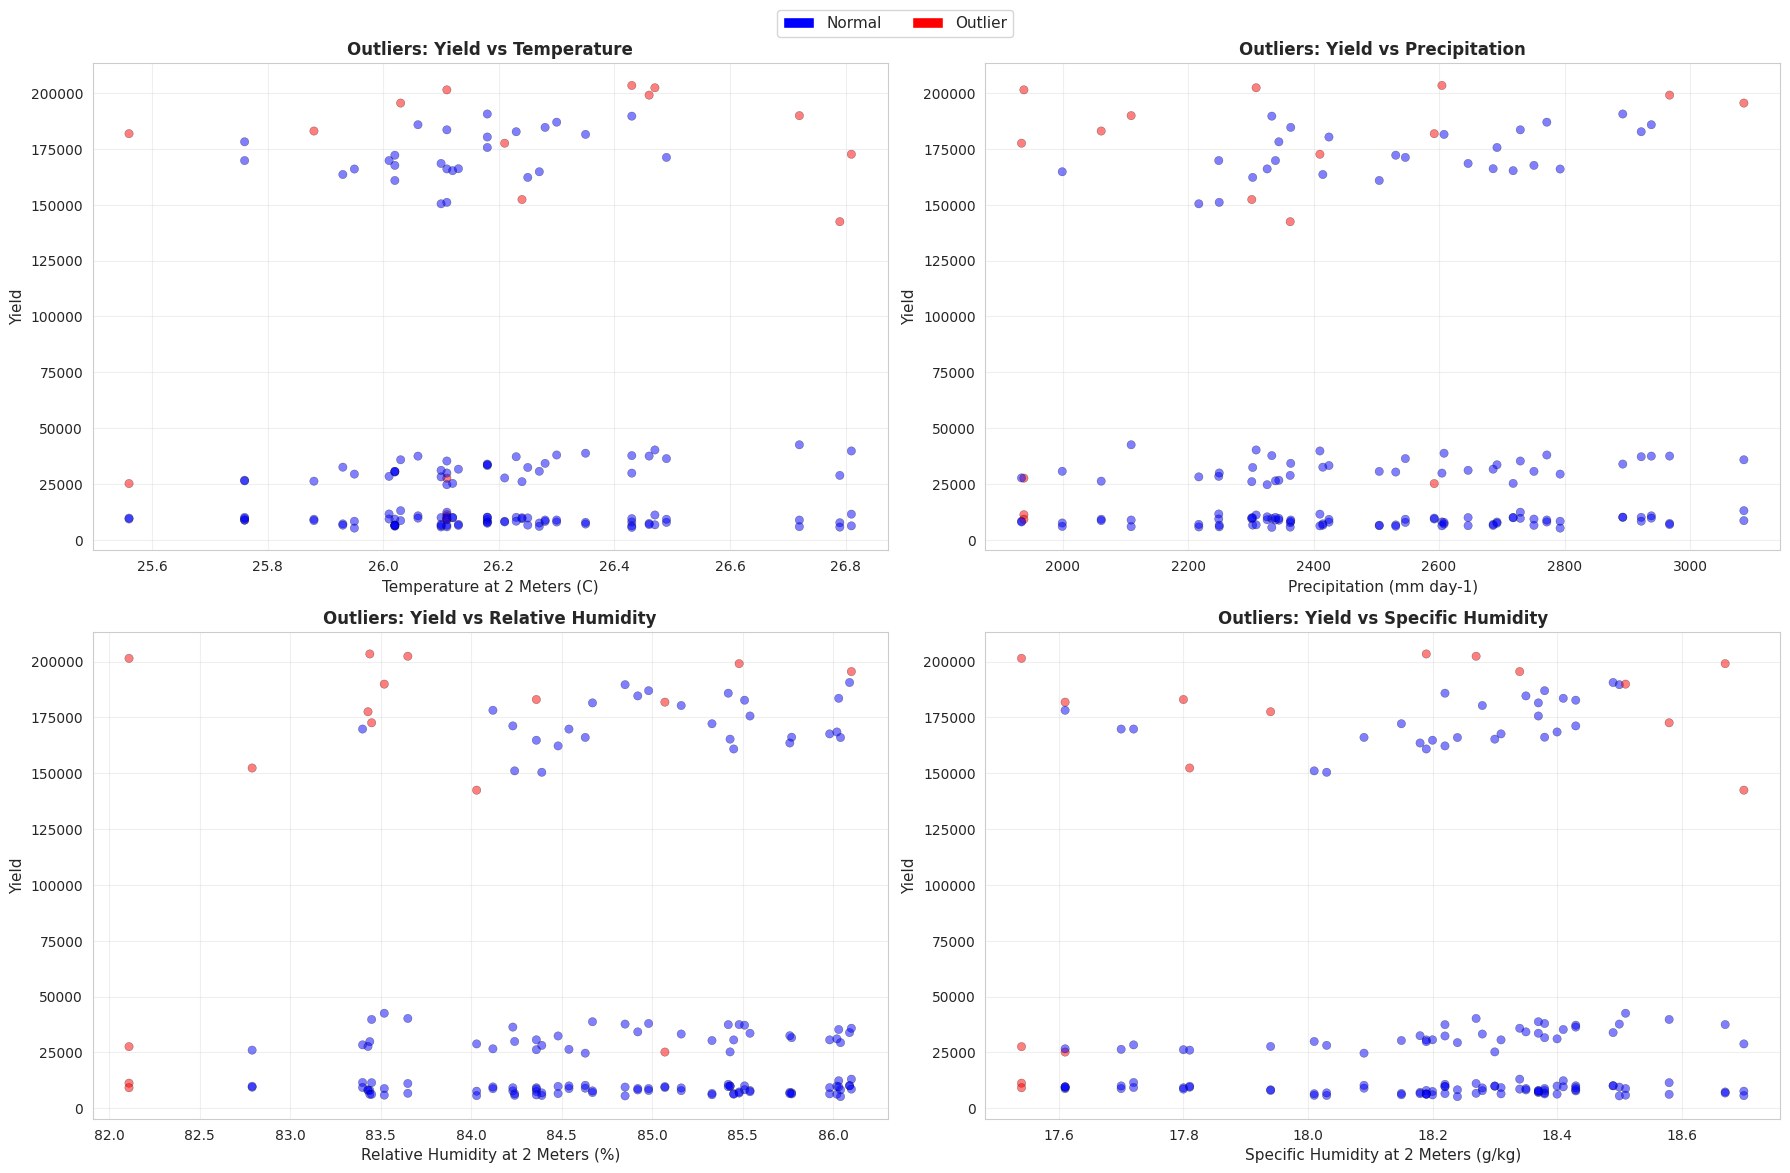

In [26]:
# Visualizar outliers
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Cores para normal vs outlier
colors = ['red' if x else 'blue' for x in df['is_outlier']]

# 1. Yield vs Temperature
axes[0, 0].scatter(df['Temperature at 2 Meters (C)'], df['Yield'],
                   c=colors, alpha=0.5, edgecolors='black', linewidth=0.3)
axes[0, 0].set_xlabel('Temperature at 2 Meters (C)', fontsize=11)
axes[0, 0].set_ylabel('Yield', fontsize=11)
axes[0, 0].set_title('Outliers: Yield vs Temperature', fontweight='bold', fontsize=12)
axes[0, 0].grid(alpha=0.3)

# 2. Yield vs Precipitation
axes[0, 1].scatter(df['Precipitation (mm day-1)'], df['Yield'],
                   c=colors, alpha=0.5, edgecolors='black', linewidth=0.3)
axes[0, 1].set_xlabel('Precipitation (mm day-1)', fontsize=11)
axes[0, 1].set_ylabel('Yield', fontsize=11)
axes[0, 1].set_title('Outliers: Yield vs Precipitation', fontweight='bold', fontsize=12)
axes[0, 1].grid(alpha=0.3)

# 3. Yield vs Relative Humidity
axes[1, 0].scatter(df['Relative Humidity at 2 Meters (%)'], df['Yield'],
                   c=colors, alpha=0.5, edgecolors='black', linewidth=0.3)
axes[1, 0].set_xlabel('Relative Humidity at 2 Meters (%)', fontsize=11)
axes[1, 0].set_ylabel('Yield', fontsize=11)
axes[1, 0].set_title('Outliers: Yield vs Relative Humidity', fontweight='bold', fontsize=12)
axes[1, 0].grid(alpha=0.3)

# 4. Yield vs Specific Humidity
axes[1, 1].scatter(df['Specific Humidity at 2 Meters (g/kg)'], df['Yield'],
                   c=colors, alpha=0.5, edgecolors='black', linewidth=0.3)
axes[1, 1].set_xlabel('Specific Humidity at 2 Meters (g/kg)', fontsize=11)
axes[1, 1].set_ylabel('Yield', fontsize=11)
axes[1, 1].set_title('Outliers: Yield vs Specific Humidity', fontweight='bold', fontsize=12)
axes[1, 1].grid(alpha=0.3)

# Legenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='Normal'),
                   Patch(facecolor='red', label='Outlier')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2,
           bbox_to_anchor=(0.5, 0.98), fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 📝 8. Conclusões da Análise Exploratória

### 📋 Principais Achados:

In [27]:
# Resumo dos achados
print('📊 RESUMO DA ANÁLISE EXPLORATÓRIA')
print('='*90)
print(f'\n1. QUALIDADE DOS DADOS:')
print(f'   - Total de registros: {len(df):,}')
print(f'   - Valores nulos: {df.isnull().sum().sum()}')
print(f'   - Linhas duplicadas: {df.duplicated().sum()}')
print(f'   ✅ Dataset limpo e pronto para modelagem!')

print(f'\n2. CULTURAS:')
print(f'   - Número de culturas diferentes: {df["Crop"].nunique()}')
print(f'   - Culturas: {df["Crop"].unique().tolist()}')

print(f'\n3. RENDIMENTO (YIELD):')
print(f'   - Média geral: {df["Yield"].mean():.2f}')
print(f'   - Desvio padrão: {df["Yield"].std():.2f}')
print(f'   - Mínimo: {df["Yield"].min():.2f}')
print(f'   - Máximo: {df["Yield"].max():.2f}')

print(f'\n4. CORRELAÇÕES COM YIELD:')
top_correlations = correlation_matrix['Yield'].drop('Yield').sort_values(ascending=False)
for var, corr in top_correlations.items():
    print(f'   - {var}: {corr:.3f}')

print(f'\n5. OUTLIERS:')
print(f'   - Total de outliers detectados (Isolation Forest): {n_outliers_iso} ({(n_outliers_iso/len(df)*100):.2f}%)')

print('\n'+'='*90)
print('🎯 PRÓXIMOS PASSOS:')
print('  1. Análise de Clusterização (K-Means, DBSCAN)')
print('  2. Desenvolvimento de 5 Modelos Preditivos de Regressão')
print('  3. Avaliação e Comparação dos Modelos (R², RMSE, MAE, MAPE)')
print('='*90)

📊 RESUMO DA ANÁLISE EXPLORATÓRIA

1. QUALIDADE DOS DADOS:
   - Total de registros: 156
   - Valores nulos: 0
   - Linhas duplicadas: 0
   ✅ Dataset limpo e pronto para modelagem!

2. CULTURAS:
   - Número de culturas diferentes: 4
   - Culturas: ['Cocoa, beans', 'Oil palm fruit', 'Rice, paddy', 'Rubber, natural']

3. RENDIMENTO (YIELD):
   - Média geral: 56153.10
   - Desvio padrão: 70421.96
   - Mínimo: 5249.00
   - Máximo: 203399.00

4. CORRELAÇÕES COM YIELD:
   - Precipitation (mm day-1): 0.019
   - Temperature at 2 Meters (C): 0.013
   - Specific Humidity at 2 Meters (g/kg): 0.013
   - Relative Humidity at 2 Meters (%): 0.000

5. OUTLIERS:
   - Total de outliers detectados (Isolation Forest): 16 (10.26%)

🎯 PRÓXIMOS PASSOS:
  1. Análise de Clusterização (K-Means, DBSCAN)
  2. Desenvolvimento de 5 Modelos Preditivos de Regressão
  3. Avaliação e Comparação dos Modelos (R², RMSE, MAE, MAPE)
